<a href="https://colab.research.google.com/github/marcusslongweek/Homework/blob/main/CS4410HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Loading the Dataset

In [54]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
B_Cancer = load_breast_cancer()
print(B_Cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

### Checking the Sample and Target Sizes

In [55]:
# With this code, we can check that there's only two classes (binary classification)
B_Cancer.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [56]:
# Confirm the number of samples and features(per sample)
B_Cancer.data.shape

(569, 30)

In [57]:
# Confirm how many targets
B_Cancer.target.shape

(569,)

###Splitting the Data for Training and Testing

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(B_Cancer.data, B_Cancer.target, test_size=0.2, random_state=2)

###Training and Testing Set Sizes

In [59]:
X_train.shape

(455, 30)

In [60]:
X_test.shape

(114, 30)

###Creating the Model (GaussianNB)

In [61]:
from sklearn.naive_bayes import GaussianNB

# Create a Gaussian Naive Bayes classifier
model = GaussianNB()

In [62]:
# Train the model
model.fit(X_train, y_train)

GaussianNB()

In [63]:
# Make predictions on the test set
y_pred = model.predict(X_test)

In [64]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9386


In [65]:
# Get the model's score on the test data
model_score = model.score(X_test, y_test)
print(f"Model Score (Accuracy): {model_score:.4f}")

Model Score (Accuracy): 0.9386


### Confusion Matrix

In [66]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

cm

array([[42,  3],
       [ 4, 65]])

###Visualization of Confusion Matrix

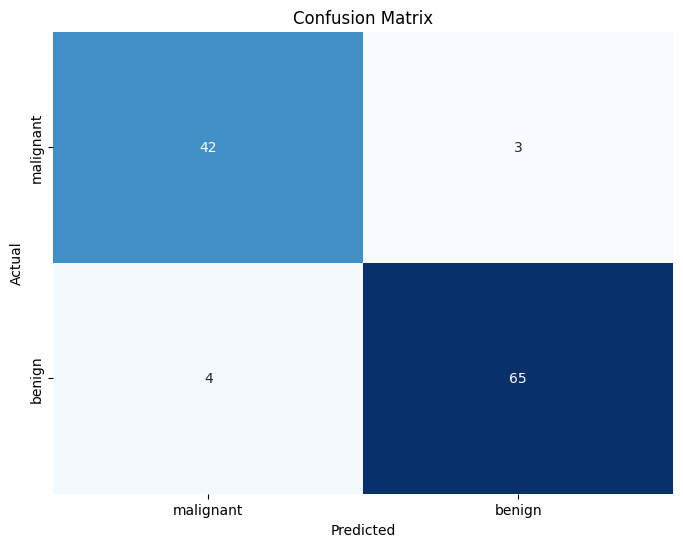

In [67]:
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=B_Cancer.target_names, yticklabels=B_Cancer.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Classification Report

In [68]:
# Generate the classification report
report = classification_report(y_test, y_pred, target_names=B_Cancer.target_names, output_dict=True)
print(classification_report(y_test, y_pred, target_names=B_Cancer.target_names))

              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        45
      benign       0.96      0.94      0.95        69

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.94       114
weighted avg       0.94      0.94      0.94       114



### Visualization of Classification Report

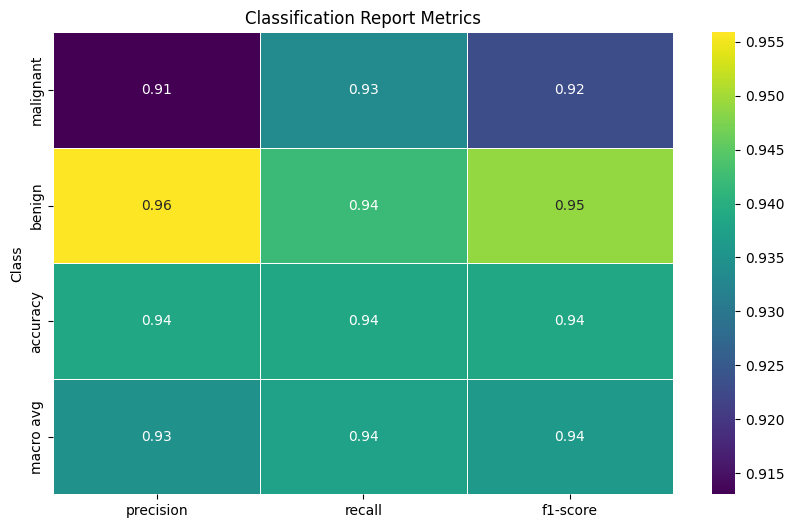

In [69]:
df_report = pd.DataFrame(report).transpose()
df_report = df_report.iloc[:-1, :3] # Exclude 'accuracy' and 'support' rows, keep precision, recall, f1-score

plt.figure(figsize=(10, 6))
sns.heatmap(df_report.iloc[:, :], annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Classification Report Metrics')
plt.ylabel('Class')
plt.show()

### K-Fold Cross Validation

In [70]:
from sklearn.model_selection import KFold
kFold = KFold(n_splits=10, random_state=11, shuffle=True)
from sklearn.model_selection import cross_val_score
scores = cross_val_score(estimator=model, X=B_Cancer.data, y=B_Cancer.target, cv=kFold)

### Running Multiple Models to Find the Best One

In [71]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

estimators = {
    'GaussianNB': model,
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(solver='lbfgs', multi_class='ovr', max_iter=10000),
    'SVC': SVC(gamma='scale')
}

In [72]:
import warnings
warnings.filterwarnings('ignore') # Removes warning labels

for name, estimator in estimators.items():
    scores = cross_val_score(estimator=estimator, X=B_Cancer.data, y=B_Cancer.target, cv=kFold)
    print(f"{name}: mean accuracy = {scores.mean():.4f}, standard deviation = {scores.std():.4f}")

GaussianNB: mean accuracy = 0.9385, standard deviation = 0.0275
KNeighborsClassifier: mean accuracy = 0.9279, standard deviation = 0.0201
LogisticRegression: mean accuracy = 0.9508, standard deviation = 0.0302
SVC: mean accuracy = 0.9192, standard deviation = 0.0352
